# Fase 4 — Comparación final: Nested CV y test oficial (IroSvA)

Este notebook **no entrena nada**. Lee los resultados que ya guardaron los notebooks de modelos y genera las tablas y figuras de la comparación final:

0. **Nested CV (solo train):** F1 de los 5 Outer Folds de todos los modelos, en una tabla y una figura comunes;
1. tabla resumen por variante y modelo (F1-Macro, F1 de la clase irónica, AUC-ROC, AP y F1-Macro sin los textos que coinciden con el train);
2. **curva ROC** comparativa: una figura con un panel por variante (MX, ES, CU);
3. **curva Precision-Recall** comparativa, con la misma estructura;
4. **matrices de confusión** normalizadas por clase real.

Requisitos: haber ejecutado el test oficial de ML, Hard Voting, BETO, DistilBETO y RoBERTuito. Si falta alguno, el notebook lo indica y continúa con los disponibles.

**Modelo de ML en las figuras.** Para no saturar las figuras, de ML se muestra un solo modelo por variante: el de mayor F1-Macro en la **Nested CV** entre LR, RF y XGBoost (nunca se elige mirando el test). Hard Voting aparece en la tabla y en las matrices de confusión, pero no en ROC ni Precision-Recall porque vota por clase y no produce probabilidades.

**Transformers.** Cada uno tiene 5 semillas: las curvas son la media de las 5 (banda = ± desviación estándar) y las métricas se reportan como media ± desviación.

## 1. Librerías y entorno

Importaciones y versiones de los paquetes utilizados.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import (
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
)
import sklearn
import matplotlib

VERSIONES = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
}
print("Versiones:", " | ".join(f"{k} {v}" for k, v in VERSIONES.items()))

Versiones: numpy 1.26.4 | pandas 3.0.3 | sklearn 1.8.0 | matplotlib 3.10.9


## 2. Configuración

Rutas de las predicciones de cada modelo y colores fijos para todas las figuras.

In [2]:
DATA_DIR = Path("../data")
OUT_DIR = DATA_DIR / "resultados_comparacion_final"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VARIANTES = ["mx", "es", "cu"]

ML_DIR = DATA_DIR / "resultados_ml_groupcv_tfidf_lr_rf_10k"
ML_PREDICCIONES = ML_DIR / "predicciones_test_ml.csv"
ML_NESTED = ML_DIR / "resumen_nested_ml.csv"
HV_PREDICCIONES = (
    DATA_DIR / "resultados_ml_hard_voting_tfidf10k" / "hard_voting_test_predicciones.csv"
)

# Carpeta de resultados y RUN_TAG de cada Transformer.
TRANSFORMERS = {
    "BETO": (DATA_DIR / "resultados_beto_grouped_5x3_tpe20_v3", "beto", "b5x3t20_v3"),
    "DistilBETO": (
        DATA_DIR / "resultados_distilbeto_grouped_5x3_tpe20_v3",
        "distilbeto",
        "d5x3t20_v3",
    ),
    "RoBERTuito": (
        DATA_DIR / "resultados_robertuito_grouped_5x3_tpe20_v3",
        "robertuito",
        "r5x3t20_v3",
    ),
}

# Orden y color fijos en todas las figuras.
COLORES = {
    "LR": "#8c564b",
    "RF": "#7f7f7f",
    "XGBoost": "#bcbd22",
    "HardVoting": "#e377c2",
    "BETO": "#1f77b4",
    "DistilBETO": "#ff7f0e",
    "RoBERTuito": "#2ca02c",
}
print(f"[CONFIG][Comparación] salida={OUT_DIR.resolve()}")

[CONFIG][Comparación] salida=/Users/taniac/Developer/DeteccionDeSarcasmo/data/resultados_comparacion_final


## 3. Nested CV: Outer Folds de todos los modelos (solo train)

Reúne en una sola tabla los 5 Outer Folds de LR, RF, XGBoost, Hard Voting, BETO, DistilBETO y RoBERTuito, leídos de los CSV que guarda cada notebook. Es la comparación principal del desarrollo y no usa el test oficial.

- tabla `nested_cv_resumen.csv`: media ± desviación por variante y modelo;
- tabla `nested_cv_outer_folds.csv`: F1-Macro de cada Outer Fold (una columna por fold);
- figura `nested_cv_todos_los_modelos.png/.pdf`: punto grande = media, línea = ± d.e., puntos huecos = cada Outer Fold.

Los folds de ML y de cada Transformer no son idénticos (cada modelo construye sus grupos), por lo que la comparación es descriptiva.

,Variante,Modelo,F1-Macro,F1 irónico,Folds
0,MX,LR,0.645 ± 0.015,0.531 ± 0.024,5
1,MX,RF,0.631 ± 0.020,0.509 ± 0.029,5
2,MX,XGBoost,0.599 ± 0.014,0.461 ± 0.031,5
3,MX,HardVoting,0.633 ± 0.013,0.507 ± 0.017,5
4,MX,BETO,0.675 ± 0.029,0.581 ± 0.050,5
5,MX,DistilBETO,0.656 ± 0.029,0.560 ± 0.040,5
6,MX,RoBERTuito,0.715 ± 0.023,0.621 ± 0.037,5
7,ES,LR,0.702 ± 0.016,0.612 ± 0.030,5
8,ES,RF,0.696 ± 0.030,0.602 ± 0.034,5
9,ES,XGBoost,0.685 ± 0.016,0.588 ± 0.024,5


outer_1  outer_2  outer_3  outer_4  outer_5
variante modelo                                                 
mx       LR           0.6291   0.6511   0.6674   0.6403   0.6371
         RF           0.6501   0.5993   0.6319   0.6443   0.6281
         XGBoost      0.6046   0.5981   0.6052   0.6114   0.5763
         HardVoting   0.6397   0.6109   0.6338   0.6399   0.6409
         BETO         0.6725   0.6876   0.6896   0.6991   0.6268
         DistilBETO   0.6789   0.6790   0.6125   0.6692   0.6397
         RoBERTuito   0.7284   0.7138   0.6763   0.7320   0.7233
es       LR           0.6952   0.7012   0.6985   0.7291   0.6882
         RF           0.7252   0.7038   0.7085   0.6956   0.6463
         XGBoost      0.6892   0.6624   0.6987   0.6997   0.6735
         HardVoting   0.7158   0.7039   0.7311   0.7086   0.6819
         BETO         0.7356   0.7382   0.7110   0.7575   0.7358
         DistilBETO   0.7468   0.7023   0.7340   0.7234   0.7773
         RoBERTuito   0.7941   0.7572   0.7739   0.7661   0.8233
cu       LR           0.6368   0.6658   0.6676   0.6446   0.6782
         RF           0.6726   0.6560   0.6201   0.6518   0.7036
         XGBoost      0.6694   0.6284   0.6457   0.6279   0.6473
         HardVoting   0.6648   0.6478   0.6393   0.6564   0.6986
         BETO         0.7254   0.6986   0.7005   0.7407   0.7164
         DistilBETO   0.7535   0.7036   0.7141   0.7227   0.7218
         RoBERTuito   0.7770   0.7296   0.7469   0.7492   0.7560

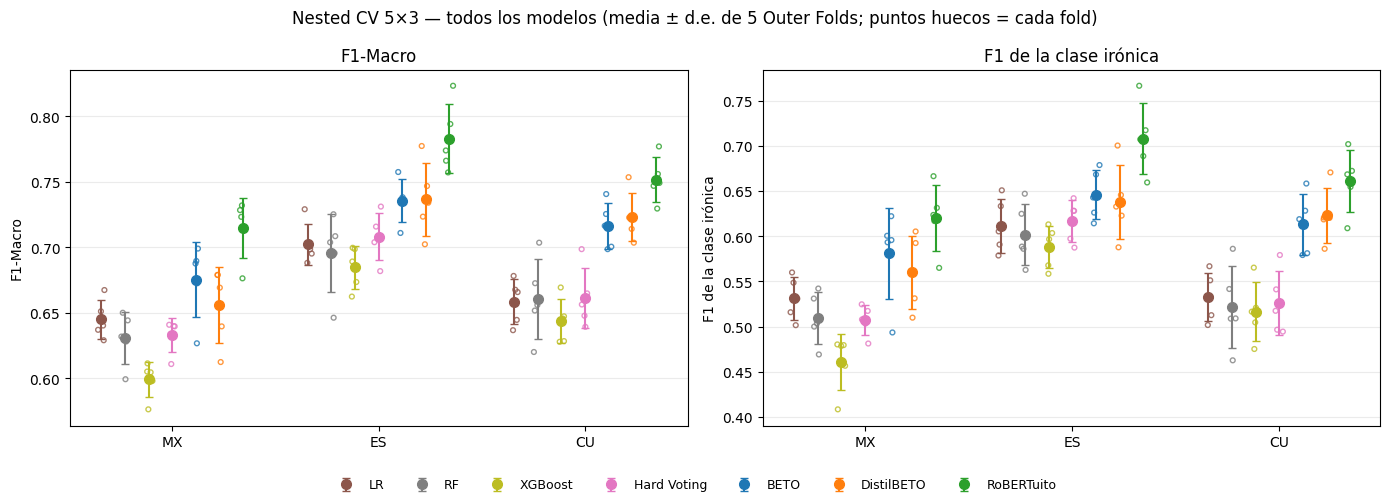

In [3]:
COLUMNAS_OUTER = ["variante", "modelo", "outer_fold", "outer_f1_macro", "outer_f1_clase_1"]
partes_outer = []

ruta = ML_DIR / "outer_folds_ml.csv"
if ruta.exists():
    partes_outer.append(pd.read_csv(ruta)[COLUMNAS_OUTER])
else:
    print(f"AVISO: falta {ruta} (Nested CV de ML no ejecutada).")

ruta = HV_PREDICCIONES.parent / "hard_voting_outer_folds.csv"
if ruta.exists():
    partes_outer.append(pd.read_csv(ruta)[COLUMNAS_OUTER])
else:
    print(f"AVISO: falta {ruta} (Nested CV de Hard Voting no ejecutada).")

for nombre, (carpeta, prefijo, _) in TRANSFORMERS.items():
    for variante in VARIANTES:
        ruta = carpeta / f"{prefijo}_nestedcv_detalle_{variante}.csv"
        if not ruta.exists():
            print(f"AVISO: falta {ruta} (Nested CV de {nombre} no ejecutada).")
            continue
        d = pd.read_csv(ruta).rename(
            columns={"f1_outer": "outer_f1_macro", "f1_outer_clase_1": "outer_f1_clase_1"}
        )
        d["modelo"] = nombre
        d["variante"] = variante
        partes_outer.append(d[COLUMNAS_OUTER])

ORDEN_NESTED = ["LR", "RF", "XGBoost", "HardVoting", *TRANSFORMERS]
COLORES_NESTED = COLORES

if not partes_outer:
    print("Todavía no hay resultados de Nested CV.")
else:
    OUTER = pd.concat(partes_outer, ignore_index=True)
    OUTER["modelo"] = pd.Categorical(OUTER["modelo"], ORDEN_NESTED, ordered=True)
    OUTER["variante"] = pd.Categorical(OUTER["variante"], VARIANTES, ordered=True)

    # --- tablas ---
    resumen_nested = (
        OUTER.groupby(["variante", "modelo"], observed=True)
        .agg(
            f1_macro_mean=("outer_f1_macro", "mean"),
            f1_macro_std=("outer_f1_macro", "std"),
            f1_ironia_mean=("outer_f1_clase_1", "mean"),
            f1_ironia_std=("outer_f1_clase_1", "std"),
            n_folds=("outer_fold", "nunique"),
        )
        .reset_index()
    )
    resumen_nested.to_csv(OUT_DIR / "nested_cv_resumen.csv", index=False)
    por_fold = OUTER.pivot_table(
        index=["variante", "modelo"], columns="outer_fold", values="outer_f1_macro", observed=True
    )
    por_fold.columns = [f"outer_{int(c)}" for c in por_fold.columns]
    por_fold.reset_index().to_csv(OUT_DIR / "nested_cv_outer_folds.csv", index=False)

    display(
        pd.DataFrame(
            {
                "Variante": resumen_nested["variante"].astype(str).str.upper(),
                "Modelo": resumen_nested["modelo"].astype(str),
                "F1-Macro": [
                    f"{m:.3f} ± {s:.3f}"
                    for m, s in zip(resumen_nested["f1_macro_mean"], resumen_nested["f1_macro_std"])
                ],
                "F1 irónico": [
                    f"{m:.3f} ± {s:.3f}"
                    for m, s in zip(
                        resumen_nested["f1_ironia_mean"], resumen_nested["f1_ironia_std"]
                    )
                ],
                "Folds": resumen_nested["n_folds"],
            }
        )
    )
    display(por_fold.round(4))

    # --- figura ---
    modelos_presentes = [m for m in ORDEN_NESTED if (OUTER["modelo"] == m).any()]
    separacion = 0.8 / max(1, len(modelos_presentes))
    rng_fig = np.random.default_rng(42)  # solo para separar los puntos de cada fold
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), squeeze=False)
    for ax, (col, titulo) in zip(
        axes[0], [("outer_f1_macro", "F1-Macro"), ("outer_f1_clase_1", "F1 de la clase irónica")]
    ):
        for k, modelo in enumerate(modelos_presentes):
            for j, variante in enumerate(VARIANTES):
                valores = OUTER.loc[
                    (OUTER["variante"] == variante) & (OUTER["modelo"] == modelo), col
                ].to_numpy()
                if len(valores) == 0:
                    continue
                x = j + (k - (len(modelos_presentes) - 1) / 2) * separacion
                ax.scatter(
                    x + rng_fig.uniform(-0.02, 0.02, len(valores)),
                    valores,
                    s=12,
                    facecolors="none",
                    edgecolors=COLORES_NESTED[modelo],
                    alpha=0.8,
                    zorder=2,
                )
                ax.errorbar(
                    x,
                    valores.mean(),
                    yerr=valores.std(ddof=1) if len(valores) > 1 else 0,
                    fmt="o",
                    ms=7,
                    capsize=3,
                    color=COLORES_NESTED[modelo],
                    zorder=3,
                    label=("Hard Voting" if modelo == "HardVoting" else modelo) if j == 0 else None,
                )
        ax.set_xticks(range(len(VARIANTES)), [v.upper() for v in VARIANTES])
        ax.set_title(titulo)
        ax.set_ylabel(titulo)
        ax.grid(axis="y", alpha=0.25)
    manejadores, etiquetas = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        manejadores, etiquetas, loc="lower center", ncol=len(etiquetas), fontsize=9, frameon=False
    )
    fig.suptitle(
        "Nested CV 5×3 — todos los modelos (media ± d.e. de 5 Outer Folds; puntos huecos = cada fold)",
        fontsize=12,
    )
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    fig.savefig(OUT_DIR / "nested_cv_todos_los_modelos.png", dpi=200, bbox_inches="tight")
    fig.savefig(OUT_DIR / "nested_cv_todos_los_modelos.pdf", bbox_inches="tight")
    display(fig)
    plt.close(fig)

## 4. Carga y verificación de predicciones

Todas las predicciones se unifican en una sola tabla con columnas `variante`, `modelo`, `seed`, `ID`, `y_true`, `y_pred` y `prob_ironia` (vacía para Hard Voting). Se verifica que cada modelo tenga los 600 textos por variante y semilla, con los mismos IDs y etiquetas que el resto.

In [4]:
partes = []

if ML_PREDICCIONES.exists():
    ml = pd.read_csv(ML_PREDICCIONES, dtype={"ID": str})
    ml["seed"] = 0
    partes.append(ml)
else:
    print(f"AVISO: falta {ML_PREDICCIONES} (test de ML no ejecutado).")

if HV_PREDICCIONES.exists():
    hv = pd.read_csv(HV_PREDICCIONES, dtype={"ID": str})
    hv["seed"] = 0
    hv["prob_ironia"] = np.nan
    partes.append(hv)
else:
    print(f"AVISO: falta {HV_PREDICCIONES} (test de Hard Voting no ejecutado).")

for nombre, (carpeta, prefijo, _) in TRANSFORMERS.items():
    ruta = carpeta / f"{prefijo}_test_probabilidades.csv"
    if ruta.exists():
        d = pd.read_csv(ruta, dtype={"ID": str})
        d["modelo"] = nombre
        partes.append(d)
    else:
        print(f"AVISO: falta {ruta} (test de {nombre} no ejecutado).")

if not partes:
    raise FileNotFoundError(
        "No hay predicciones del test. Ejecuta primero el test oficial de los modelos."
    )

columnas = ["variante", "modelo", "seed", "ID", "y_true", "y_pred", "prob_ironia"]
PRED = pd.concat([p[columnas] for p in partes], ignore_index=True)
PRED["ID"] = PRED["ID"].astype(str)

# ---------------- verificaciones ----------------
referencia = {}
for (variante, modelo, seed), g in PRED.groupby(["variante", "modelo", "seed"]):
    if len(g) != 600 or g["ID"].duplicated().any():
        raise ValueError(
            f"{variante}/{modelo}/semilla {seed}: se esperaban 600 IDs únicos, hay {len(g)}."
        )
    etiquetas = g.set_index("ID")["y_true"].sort_index()
    if variante not in referencia:
        referencia[variante] = etiquetas
    elif not etiquetas.equals(referencia[variante]):
        raise ValueError(
            f"{variante}/{modelo}/semilla {seed}: IDs o etiquetas distintos al resto de modelos."
        )

print("Predicciones verificadas:")
display(
    PRED.groupby(["variante", "modelo"])
    .agg(semillas=("seed", "nunique"), textos=("ID", "nunique"))
    .reset_index()
)

Predicciones verificadas:


,variante,modelo,semillas,textos
0,cu,BETO,5,600
1,cu,DistilBETO,5,600
2,cu,HardVoting,1,600
3,cu,LR,1,600
4,cu,RF,1,600
5,cu,RoBERTuito,5,600
6,cu,XGBoost,1,600
7,es,BETO,5,600
8,es,DistilBETO,5,600
9,es,HardVoting,1,600


## 5. Textos del test que coinciden con el train (conjunto común)

Para que el análisis de sensibilidad sea **igual para todos los modelos**, se usa un único conjunto de textos excluidos por variante: la unión de las coincidencias detectadas por los tres Transformers (mismo `MESSAGE` original o misma secuencia de tokens de entrada) más las coincidencias exactas del `MESSAGE` original entre los CSV de train y test. Este conjunto solo se usa para recalcular el F1; no interviene en ninguna decisión de los modelos.

In [5]:
def colapsar(texto):
    return re.sub(r"\s+", " ", str(texto)).strip()


IDS_COINCIDENTES = {}
for variante in VARIANTES:
    ids = set()
    # Coincidencias registradas por cada Transformer en su auditoría del test.
    for nombre, (carpeta, _, run_tag) in TRANSFORMERS.items():
        auditoria = carpeta / "seguimiento" / run_tag / "completo" / "audit"
        for ruta in auditoria.glob(f"coincidencias_test_train_{variante}_*.csv"):
            ids |= set(pd.read_csv(ruta, dtype={"ID": str})["ID"].astype(str))
    # Coincidencia exacta del MESSAGE original (no depende de ningún modelo).
    ruta_tr = DATA_DIR / f"train_clean_{variante}.csv"
    ruta_te = DATA_DIR / f"test_clean_{variante}.csv"
    if ruta_tr.exists() and ruta_te.exists():
        tr = pd.read_csv(ruta_tr, dtype={"ID": str})
        te = pd.read_csv(ruta_te, dtype={"ID": str})
        originales = set(tr["MESSAGE"].map(colapsar))
        ids |= set(te.loc[te["MESSAGE"].map(colapsar).isin(originales), "ID"].astype(str))
    IDS_COINCIDENTES[variante] = ids

PRED["coincide_train"] = [
    i in IDS_COINCIDENTES.get(v, set()) for v, i in zip(PRED["variante"], PRED["ID"])
]
df_coincidencias = pd.DataFrame(
    [{"variante": v, "textos_coincidentes": len(IDS_COINCIDENTES[v])} for v in VARIANTES]
)
csv_coinc = pd.DataFrame(
    [{"variante": v, "ID": i} for v in VARIANTES for i in sorted(IDS_COINCIDENTES[v])]
)
csv_coinc.to_csv(OUT_DIR / "ids_test_coincidentes_con_train.csv", index=False)
display(df_coincidencias)

,variante,textos_coincidentes
0,mx,2
1,es,23
2,cu,1


## 6. Selección del modelo de ML para las figuras

Se elige por variante el modelo de ML con mayor F1-Macro en la **Nested CV** (solo train), entre los que producen probabilidades.

In [6]:
ML_EN_FIGURAS = {}
if ML_NESTED.exists() and (PRED["modelo"].isin(["LR", "RF", "XGBoost"])).any():
    nested = pd.read_csv(ML_NESTED)
    for variante in VARIANTES:
        candidatos = nested[
            (nested["variante"] == variante) & nested["modelo"].isin(["LR", "RF", "XGBoost"])
        ]
        if not candidatos.empty:
            fila = candidatos.sort_values("f1_nested_mean", ascending=False).iloc[0]
            ML_EN_FIGURAS[variante] = fila["modelo"]
            print(
                f"{variante.upper()}: {fila['modelo']} (F1 Nested CV = {fila['f1_nested_mean']:.4f})"
            )
else:
    print("Sin resultados de ML: las figuras mostrarán solo los Transformers.")


def modelos_en_figura(variante):
    """(etiqueta en la figura, nombre del modelo en PRED) en orden fijo."""
    salida = []
    if variante in ML_EN_FIGURAS:
        salida.append((f"ML ({ML_EN_FIGURAS[variante]})", ML_EN_FIGURAS[variante]))
    for nombre in TRANSFORMERS:
        if ((PRED["variante"] == variante) & (PRED["modelo"] == nombre)).any():
            salida.append((nombre, nombre))
    return salida


def color(etiqueta):
    """Color fijo por modelo; «ML (LR)» usa el color de LR."""
    if etiqueta.startswith("ML ("):
        etiqueta = etiqueta[len("ML (") : -1]
    return COLORES[etiqueta]

MX: LR (F1 Nested CV = 0.6450)
ES: LR (F1 Nested CV = 0.7024)
CU: RF (F1 Nested CV = 0.6608)


## 7. Tabla resumen del test oficial

Para cada semilla se calculan las métricas y luego la media ± desviación (ML y Hard Voting tienen una sola ejecución). `F1-Macro sin coincidencias` usa el conjunto común de la sección 5.

In [7]:
filas = []
for (variante, modelo, seed), g in PRED.groupby(["variante", "modelo", "seed"]):
    limpio = g[~g["coincide_train"]]
    tiene_prob = g["prob_ironia"].notna().all()
    filas.append(
        {
            "variante": variante,
            "modelo": modelo,
            "seed": seed,
            "f1_macro": f1_score(g["y_true"], g["y_pred"], average="macro"),
            "f1_ironia": f1_score(g["y_true"], g["y_pred"], pos_label=1, zero_division=0),
            "f1_macro_sin_coincidencias": f1_score(
                limpio["y_true"], limpio["y_pred"], average="macro"
            ),
            "auc_roc": roc_auc_score(g["y_true"], g["prob_ironia"]) if tiene_prob else np.nan,
            "average_precision": (
                average_precision_score(g["y_true"], g["prob_ironia"]) if tiene_prob else np.nan
            ),
        }
    )
METRICAS = pd.DataFrame(filas)

metricas = ["f1_macro", "f1_ironia", "f1_macro_sin_coincidencias", "auc_roc", "average_precision"]
resumen = METRICAS.groupby(["variante", "modelo"])[metricas].agg(["mean", "std"])
resumen.columns = [f"{m}_{e}" for m, e in resumen.columns]
resumen = resumen.reset_index()
resumen["n_semillas"] = METRICAS.groupby(["variante", "modelo"])["seed"].nunique().to_numpy()

orden_modelos = ["LR", "RF", "XGBoost", "HardVoting", *TRANSFORMERS]
resumen["modelo"] = pd.Categorical(resumen["modelo"], orden_modelos, ordered=True)
resumen["variante"] = pd.Categorical(resumen["variante"], VARIANTES, ordered=True)
resumen = resumen.sort_values(["variante", "modelo"]).reset_index(drop=True)
resumen.to_csv(OUT_DIR / "tabla_resumen_test.csv", index=False)
METRICAS.to_csv(OUT_DIR / "metricas_test_por_semilla.csv", index=False)


def media_std(m, s):
    if pd.isna(m):
        return "—"
    return f"{m:.3f}" if pd.isna(s) else f"{m:.3f} ± {s:.3f}"


tabla_informe = pd.DataFrame(
    {
        "Variante": resumen["variante"].astype(str).str.upper(),
        "Modelo": resumen["modelo"].astype(str),
        "F1-Macro": [
            media_std(m, s) for m, s in zip(resumen["f1_macro_mean"], resumen["f1_macro_std"])
        ],
        "F1 irónico": [
            media_std(m, s) for m, s in zip(resumen["f1_ironia_mean"], resumen["f1_ironia_std"])
        ],
        "F1-Macro sin coincidencias": [
            media_std(m, s)
            for m, s in zip(
                resumen["f1_macro_sin_coincidencias_mean"],
                resumen["f1_macro_sin_coincidencias_std"],
            )
        ],
        "AUC-ROC": [
            media_std(m, s) for m, s in zip(resumen["auc_roc_mean"], resumen["auc_roc_std"])
        ],
        "AP": [
            media_std(m, s)
            for m, s in zip(resumen["average_precision_mean"], resumen["average_precision_std"])
        ],
    }
)
tabla_informe.to_csv(OUT_DIR / "tabla_resumen_test_informe.csv", index=False)
display(tabla_informe)

,Variante,Modelo,F1-Macro,F1 irónico,F1-Macro sin coincidencias,AUC-ROC,AP
0,MX,LR,0.692,0.587,0.693,0.742,0.596
1,MX,RF,0.661,0.555,0.664,0.739,0.574
2,MX,XGBoost,0.667,0.561,0.666,0.723,0.543
3,MX,HardVoting,0.678,0.573,0.679,—,—
4,MX,BETO,0.688 ± 0.011,0.617 ± 0.013,0.689 ± 0.011,0.780 ± 0.014,0.601 ± 0.026
5,MX,DistilBETO,0.704 ± 0.009,0.613 ± 0.014,0.705 ± 0.009,0.782 ± 0.008,0.609 ± 0.025
6,MX,RoBERTuito,0.760 ± 0.009,0.668 ± 0.013,0.760 ± 0.009,0.861 ± 0.006,0.749 ± 0.013
7,ES,LR,0.719,0.639,0.712,0.808,0.673
8,ES,RF,0.728,0.623,0.722,0.823,0.666
9,ES,XGBoost,0.703,0.608,0.696,0.784,0.646


## 8. Curva ROC comparativa

Una figura con un panel por variante. En cada panel, todos los modelos evaluados sobre los mismos 600 textos. Para los Transformers, la curva es la media de las 5 semillas (interpolada sobre una rejilla común de tasa de falsos positivos) con banda de ± desviación estándar; la leyenda muestra el AUC medio ± desviación.

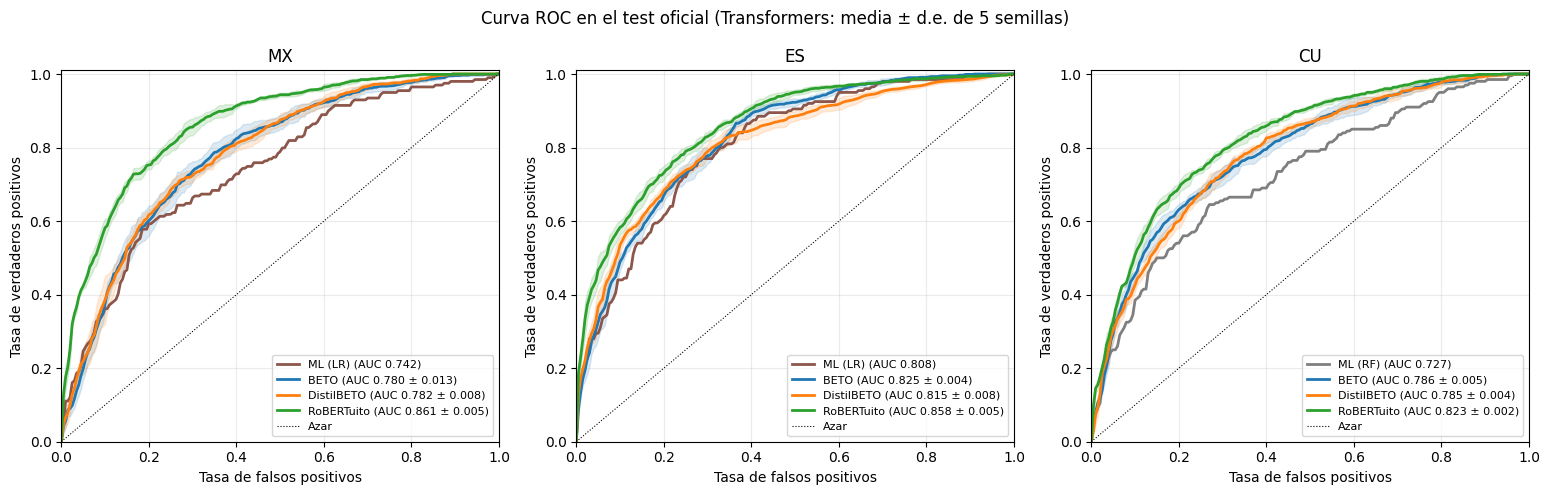

In [8]:
REJILLA = np.linspace(0, 1, 201)


def curva_media(g, tipo):
    """Curva media sobre semillas en la rejilla común."""
    curvas, areas = [], []
    for _, s in g.groupby("seed"):
        if tipo == "roc":
            x, y, _ = roc_curve(s["y_true"], s["prob_ironia"])
            interp = np.interp(REJILLA, x, y)
            interp[0] = 0.0
            areas.append(roc_auc_score(s["y_true"], s["prob_ironia"]))
        else:
            precision, recall, _ = precision_recall_curve(s["y_true"], s["prob_ironia"])
            interp = np.interp(REJILLA, recall[::-1], precision[::-1])
            areas.append(average_precision_score(s["y_true"], s["prob_ironia"]))
        curvas.append(interp)
    curvas = np.vstack(curvas)
    return curvas.mean(axis=0), curvas.std(axis=0), np.mean(areas), np.std(areas), len(areas)


def figura_comparativa(tipo):
    variantes = [v for v in VARIANTES if (PRED["variante"] == v).any()]
    fig, axes = plt.subplots(1, len(variantes), figsize=(5.2 * len(variantes), 5.0), squeeze=False)
    for ax, variante in zip(axes[0], variantes):
        for etiqueta, modelo in modelos_en_figura(variante):
            g = PRED[(PRED["variante"] == variante) & (PRED["modelo"] == modelo)]
            if g["prob_ironia"].isna().any():
                continue
            media, std, area, area_std, n = curva_media(g, tipo)
            nombre_area = "AUC" if tipo == "roc" else "AP"
            texto = f"{area:.3f}" if n == 1 else f"{area:.3f} ± {area_std:.3f}"
            ax.plot(
                REJILLA,
                media,
                color=color(etiqueta),
                lw=2,
                label=f"{etiqueta} ({nombre_area} {texto})",
            )
            if n > 1:
                ax.fill_between(
                    REJILLA,
                    np.clip(media - std, 0, 1),
                    np.clip(media + std, 0, 1),
                    color=color(etiqueta),
                    alpha=0.15,
                )
        if tipo == "roc":
            ax.plot([0, 1], [0, 1], color="black", lw=0.8, ls=":", label="Azar")
            ax.set_xlabel("Tasa de falsos positivos")
            ax.set_ylabel("Tasa de verdaderos positivos")
        else:
            prevalencia = (
                PRED.loc[PRED["variante"] == variante].drop_duplicates("ID")["y_true"].mean()
            )
            ax.axhline(
                prevalencia, color="black", lw=0.8, ls=":", label=f"Azar ({prevalencia:.2f})"
            )
            ax.set_xlabel("Recall (clase irónica)")
            ax.set_ylabel("Precisión (clase irónica)")
        ax.set_title(variante.upper())
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.01)
        ax.grid(alpha=0.25)
        ax.legend(loc="lower right" if tipo == "roc" else "upper right", fontsize=8)
    titulo = "Curva ROC" if tipo == "roc" else "Curva Precision-Recall"
    fig.suptitle(
        f"{titulo} en el test oficial (Transformers: media ± d.e. de 5 semillas)", fontsize=12
    )
    fig.tight_layout()
    nombre = "curva_roc_test" if tipo == "roc" else "curva_precision_recall_test"
    fig.savefig(OUT_DIR / f"{nombre}.png", dpi=200, bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{nombre}.pdf", bbox_inches="tight")
    display(fig)
    plt.close(fig)


figura_comparativa("roc")

## 9. Curva Precision-Recall comparativa

Misma estructura que la ROC. Con la clase irónica como minoría (≈ 1/3), esta curva es más sensible a las diferencias en la detección de ironía. La línea punteada es la proporción de textos irónicos (rendimiento de un clasificador al azar).

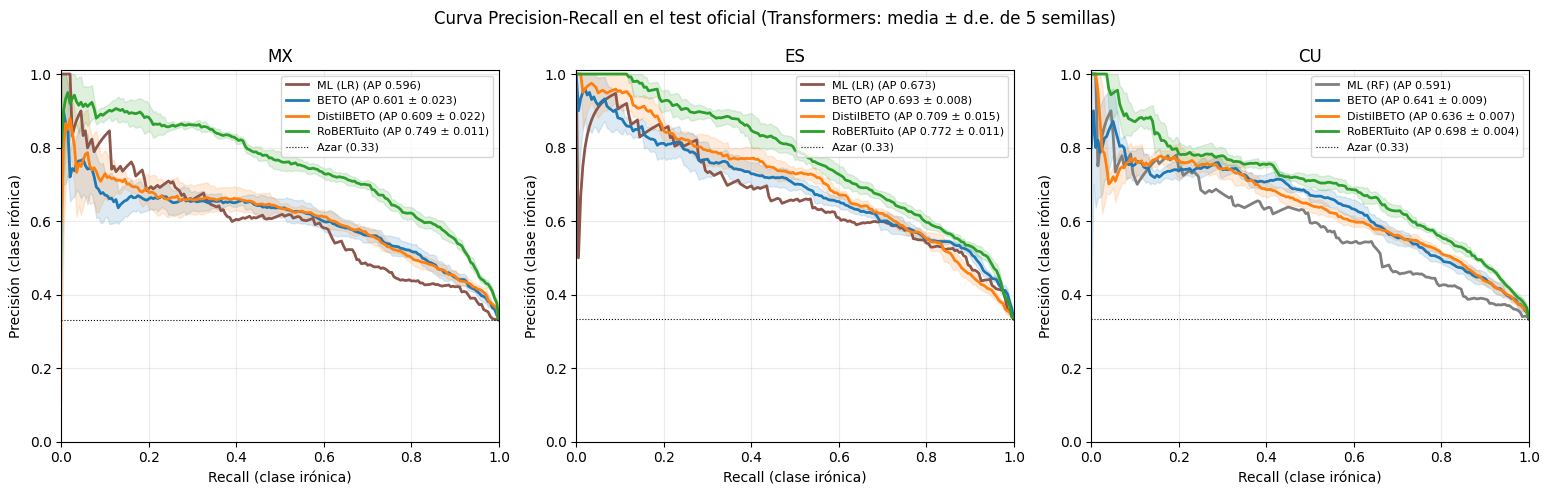

In [9]:
figura_comparativa("pr")

## 10. Matrices de confusión

Filas = modelos, columnas = variantes. Cada celda muestra el porcentaje respecto a la clase real (las filas de cada matriz suman 100 %) y, entre paréntesis, el número medio de textos. Para los Transformers se promedian las 5 semillas.

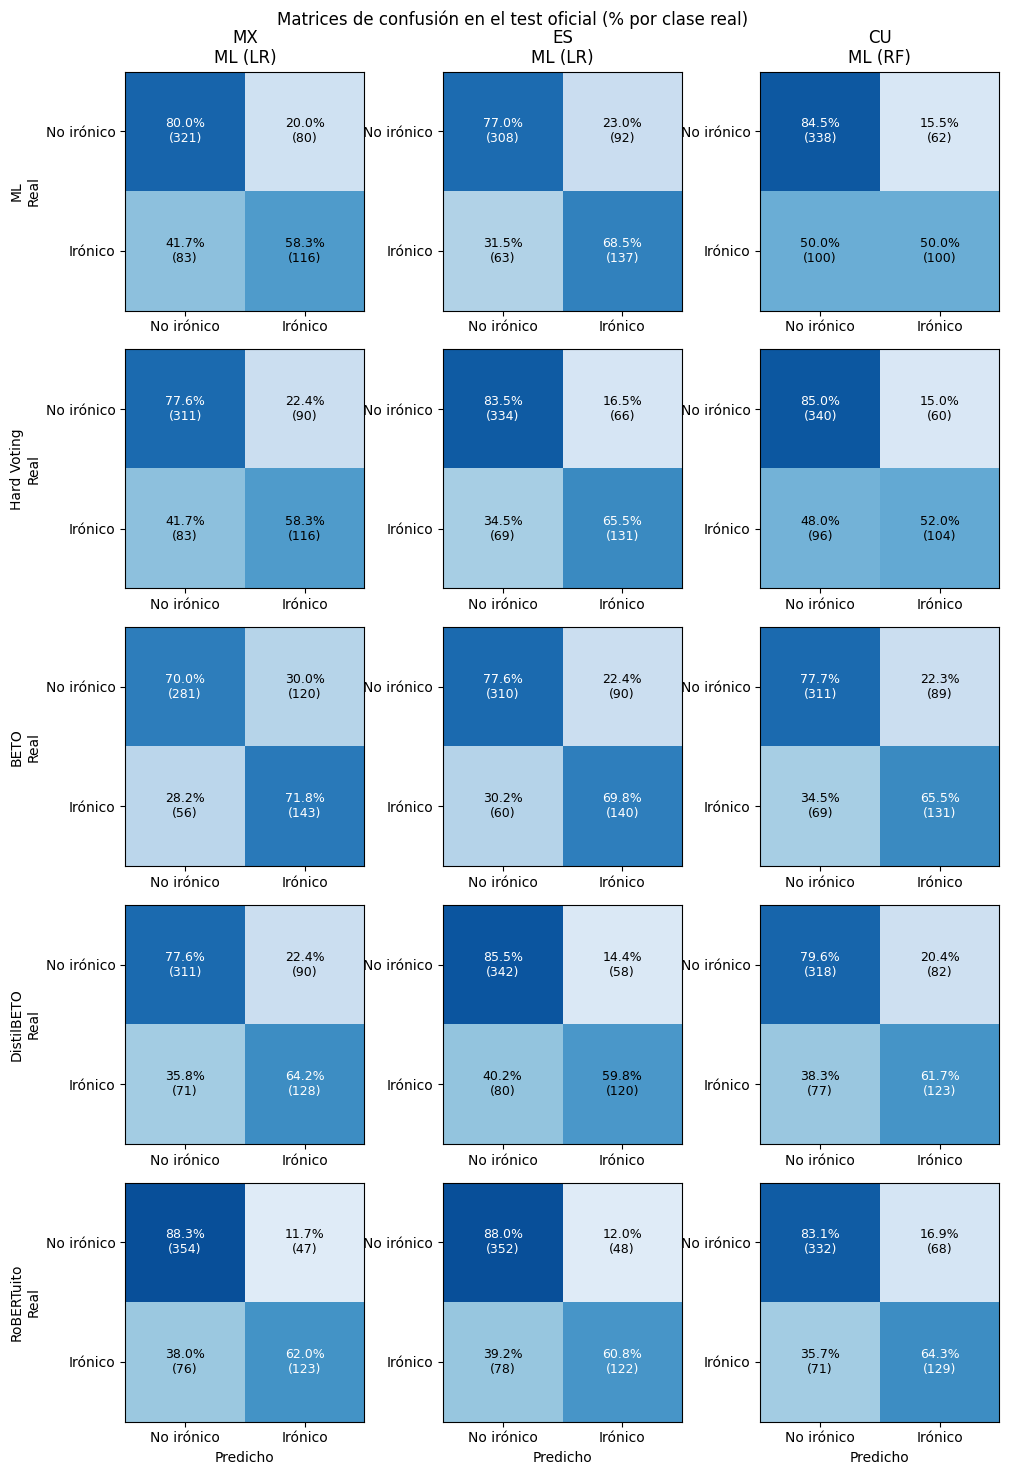

In [10]:
def modelos_en_matrices(variante):
    salida = modelos_en_figura(variante)
    if ((PRED["variante"] == variante) & (PRED["modelo"] == "HardVoting")).any():
        salida.insert(
            1 if salida and salida[0][0].startswith("ML") else 0, ("Hard Voting", "HardVoting")
        )
    return salida


variantes = [v for v in VARIANTES if (PRED["variante"] == v).any()]
etiquetas_filas = []
for v in variantes:
    for etiqueta, _ in modelos_en_matrices(v):
        clave = "ML" if etiqueta.startswith("ML") else etiqueta
        if clave not in etiquetas_filas:
            etiquetas_filas.append(clave)

fig, axes = plt.subplots(
    len(etiquetas_filas),
    len(variantes),
    figsize=(3.4 * len(variantes), 3.0 * len(etiquetas_filas)),
    squeeze=False,
)
for j, variante in enumerate(variantes):
    disponibles = {
        ("ML" if e.startswith("ML") else e): (e, m) for e, m in modelos_en_matrices(variante)
    }
    for i, clave in enumerate(etiquetas_filas):
        ax = axes[i, j]
        if clave not in disponibles:
            ax.axis("off")
            continue
        etiqueta, modelo = disponibles[clave]
        g = PRED[(PRED["variante"] == variante) & (PRED["modelo"] == modelo)]
        matrices = [
            confusion_matrix(s["y_true"], s["y_pred"], labels=[0, 1]) for _, s in g.groupby("seed")
        ]
        cuentas = np.mean(matrices, axis=0)
        porcentaje = cuentas / cuentas.sum(axis=1, keepdims=True)
        ax.imshow(porcentaje, cmap="Blues", vmin=0, vmax=1)
        for a in range(2):
            for b in range(2):
                ax.text(
                    b,
                    a,
                    f"{100 * porcentaje[a, b]:.1f}%\n({cuentas[a, b]:.0f})",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="white" if porcentaje[a, b] > 0.6 else "black",
                )
        ax.set_xticks([0, 1], ["No irónico", "Irónico"])
        ax.set_yticks([0, 1], ["No irónico", "Irónico"])
        if i == len(etiquetas_filas) - 1:
            ax.set_xlabel("Predicho")
        if j == 0:
            ax.set_ylabel(f"{clave}\nReal")
        if i == 0:
            # Si la primera fila es ML, se indica qué modelo se eligió en cada variante.
            ax.set_title(variante.upper() + (f"\n{etiqueta}" if clave == "ML" else ""))
fig.suptitle("Matrices de confusión en el test oficial (% por clase real)", fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / "matrices_confusion_test.png", dpi=200, bbox_inches="tight")
fig.savefig(OUT_DIR / "matrices_confusion_test.pdf", bbox_inches="tight")
display(fig)
plt.close(fig)

## 11. Archivos generados

En `../data/resultados_comparacion_final/`:

- `nested_cv_resumen.csv`, `nested_cv_outer_folds.csv` y `nested_cv_todos_los_modelos.png/.pdf` — Nested CV de todos los modelos;
- `tabla_resumen_test_informe.csv` — tabla lista para el informe (media ± d.e.);
- `tabla_resumen_test.csv` y `metricas_test_por_semilla.csv` — valores numéricos completos;
- `curva_roc_test.png/.pdf` y `curva_precision_recall_test.png/.pdf`;
- `matrices_confusion_test.png/.pdf`;
- `ids_test_coincidentes_con_train.csv` — textos excluidos en el análisis de sensibilidad.

Las curvas de entrenamiento se generan en cada notebook de Transformer (sección 16), porque describen el entrenamiento de cada modelo y no la comparación en el test.